# Phase 1: Imports, Data Loading

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# File system utilities
from pathlib import Path

# Display settings (so wide dataframes don't get truncated)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Suppress noisy warnings for now
import warnings
warnings.filterwarnings('ignore')

## Phase 1.2 : Dataset Loading

In [2]:
data_folder = Path(r"U:\AI\Unified-Mentor\Customer-Segmentation-Churn-Pattern-Analytics-in-European-Banking\data")

# List everything in the folder
for f in data_folder.iterdir():
    print(f.name)

European_Bank.csv


## Phase 1.3 — Load the Dataset (auto-detect file type)

In [3]:
# Auto-detect the data file in the folder (assumes one primary data file)
files = [f for f in data_folder.iterdir() if f.suffix.lower() in ['.csv', '.xlsx', '.xls']]
print("Found:", [f.name for f in files])

file_path = files[0]  # adjust index if multiple files are found

if file_path.suffix.lower() == '.csv':
    df = pd.read_csv(file_path)
else:
    df = pd.read_excel(file_path)

print(f"Loaded: {file_path.name}")
print(f"Shape: {df.shape}")

Found: ['European_Bank.csv']
Loaded: European_Bank.csv
Shape: (10000, 14)


In [4]:
# Basic structure
print(df.info())
print("\n--- First 5 rows ---")
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

--- First 5 rows ---


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate CustomerId:", df['CustomerId'].duplicated().sum())

Missing values per column:
 Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0
Duplicate CustomerId: 0


In [6]:
print("Geography values:", df['Geography'].unique())
print("Gender values:", df['Gender'].unique())
print("HasCrCard values:", df['HasCrCard'].unique())
print("IsActiveMember values:", df['IsActiveMember'].unique())
print("Exited values:", df['Exited'].unique())
print("\nAge range:", df['Age'].min(), "-", df['Age'].max())
print("CreditScore range:", df['CreditScore'].min(), "-", df['CreditScore'].max())
print("Tenure range:", df['Tenure'].min(), "-", df['Tenure'].max())
print("NumOfProducts unique:", sorted(df['NumOfProducts'].unique()))
print("Balance range:", df['Balance'].min(), "-", df['Balance'].max())

Geography values: ['France' 'Spain' 'Germany']
Gender values: ['Female' 'Male']
HasCrCard values: [1 0]
IsActiveMember values: [1 0]
Exited values: [1 0]

Age range: 18 - 92
CreditScore range: 350 - 850
Tenure range: 0 - 10
NumOfProducts unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Balance range: 0.0 - 250898.09


In [7]:
churn_rate = df['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(df['Exited'].value_counts())

Overall Churn Rate: 20.37%
Exited
0    7963
1    2037
Name: count, dtype: int64


In [8]:
print("Unique Year values:", df['Year'].unique())
print("Year value counts:\n", df['Year'].value_counts())

Unique Year values: [2025]
Year value counts:
 Year
2025    10000
Name: count, dtype: int64


# Phase 2: EDA

## Phase 2.1 — Drop Non-Analytical Fields

In [9]:
df_clean = df.drop(columns=['Year', 'Surname'])
print(df_clean.shape)
df_clean.columns.tolist()

(10000, 12)


['CustomerId',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

## Phase 2.2 — Derived Segmentation Fields

In [10]:
# --- AgeGroup (fixed bins per spec) ---
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 29, 45, 60, np.inf],
    labels=['<30', '30-45', '46-60', '60+']
)

# --- TenureGroup (fixed bins per spec) ---
df_clean['TenureGroup'] = pd.cut(
    df_clean['Tenure'],
    bins=[-1, 2, 6, np.inf],
    labels=['New', 'Mid-term', 'Long-term']
)

# --- CreditScoreBand (quantile-based tertiles) ---
df_clean['CreditScoreBand'] = pd.qcut(
    df_clean['CreditScore'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# --- BalanceSegment (fixed zero cutoff, then quantile split on non-zero) ---
zero_mask = df_clean['Balance'] == 0
non_zero_median = df_clean.loc[~zero_mask, 'Balance'].median()

def balance_segment(bal):
    if bal == 0:
        return 'Zero-balance'
    elif bal <= non_zero_median:
        return 'Low-balance'
    else:
        return 'High-balance'

df_clean['BalanceSegment'] = df_clean['Balance'].apply(balance_segment)

# Check the results
print(df_clean[['AgeGroup', 'TenureGroup', 'CreditScoreBand', 'BalanceSegment']].apply(lambda x: x.value_counts()))

              AgeGroup  TenureGroup  CreditScoreBand  BalanceSegment
30-45           6248.0          NaN              NaN             NaN
46-60           1647.0          NaN              NaN             NaN
60+              464.0          NaN              NaN             NaN
<30             1641.0          NaN              NaN             NaN
High               NaN          NaN           3303.0             NaN
High-balance       NaN          NaN              NaN          3191.0
Long-term          NaN       3527.0              NaN             NaN
Low                NaN          NaN           3363.0             NaN
Low-balance        NaN          NaN              NaN          3192.0
Medium             NaN          NaN           3334.0             NaN
Mid-term           NaN       3977.0              NaN             NaN
New                NaN       2496.0              NaN             NaN
Zero-balance       NaN          NaN              NaN          3617.0


# Phase 3: EDA

## Phase 3.1 — Imports for EDA

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Phase 3.2 — Univariate Distributions

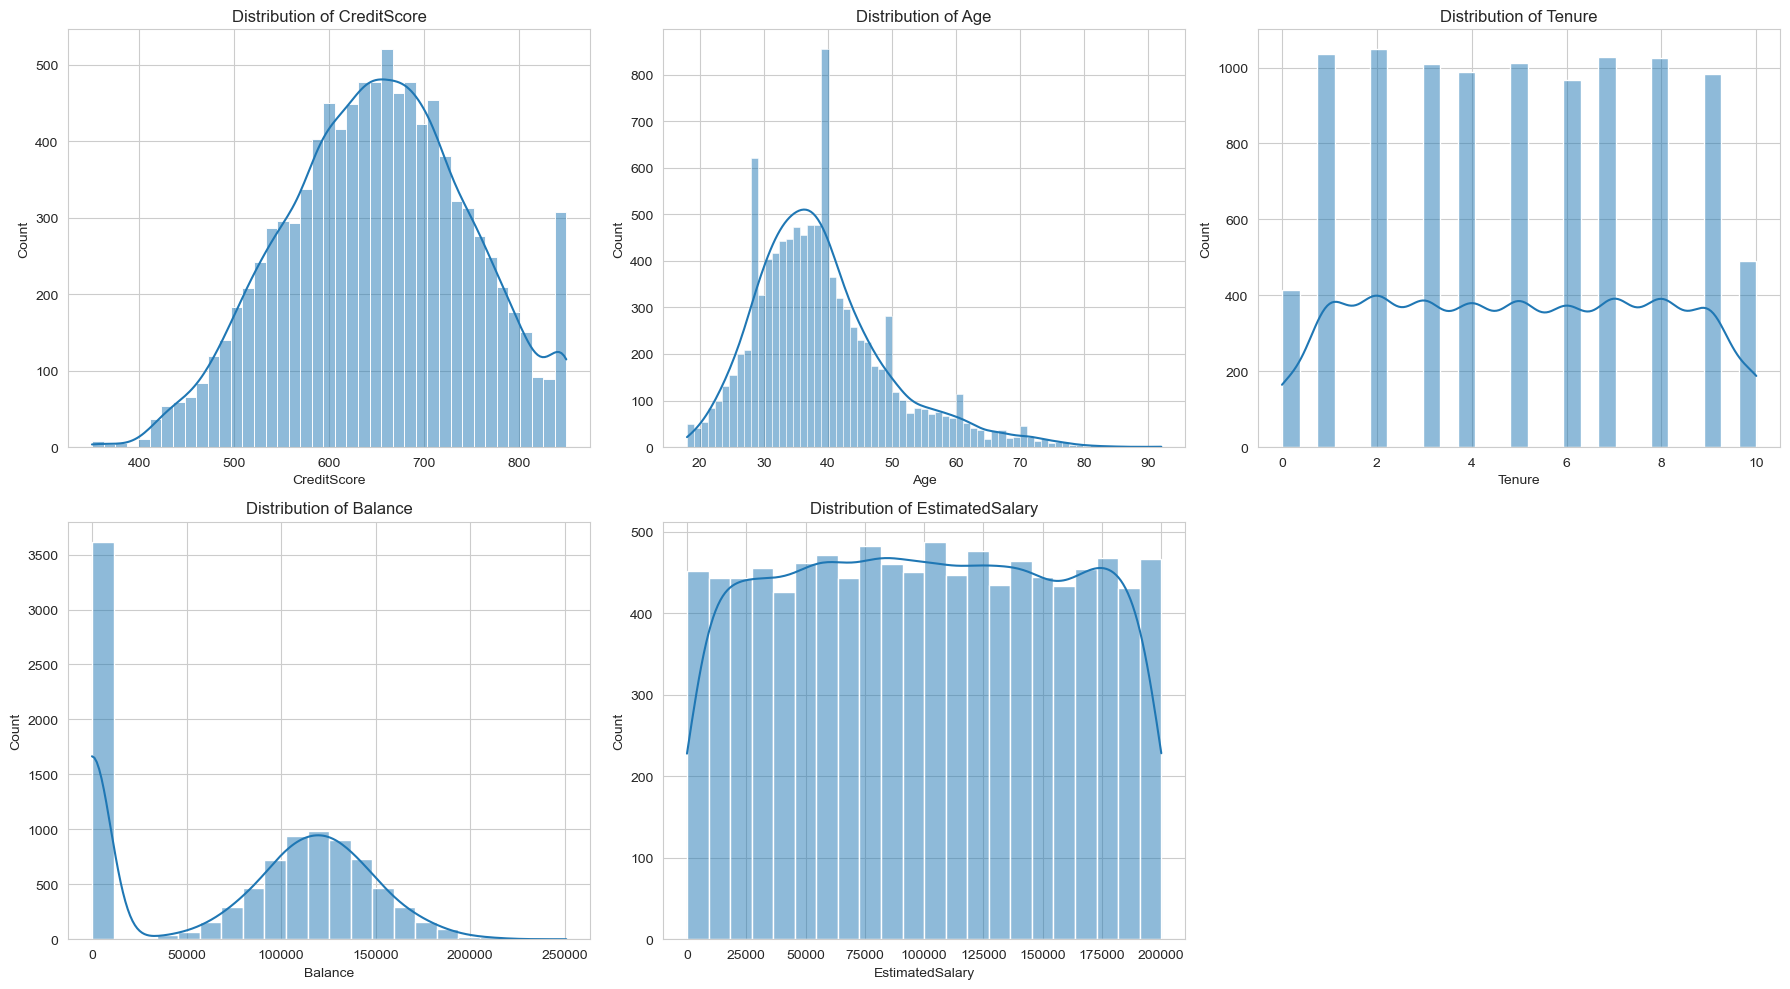

In [12]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.show()

## Phase 3.3 — Overall Churn Rate (Visual)

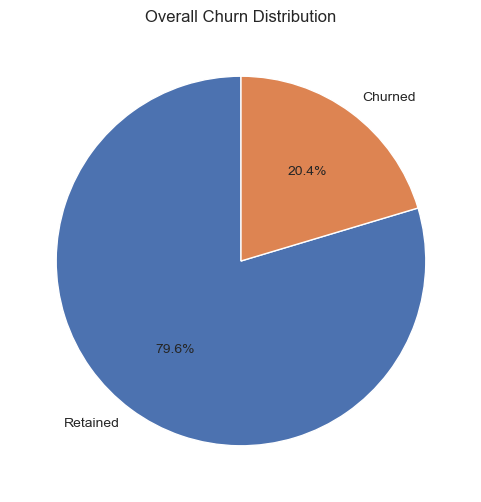

In [13]:
churn_counts = df_clean['Exited'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Overall Churn Distribution')
plt.show()

## Phase 3.4 — Segment-wise Churn Rates

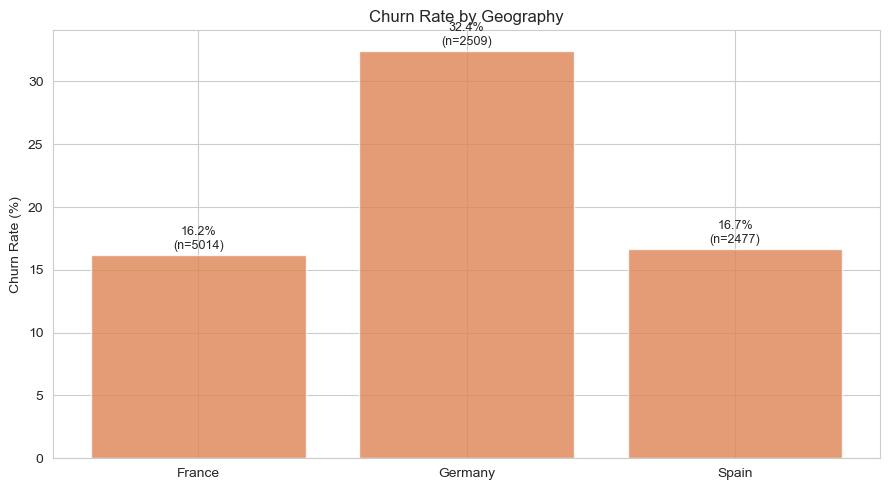

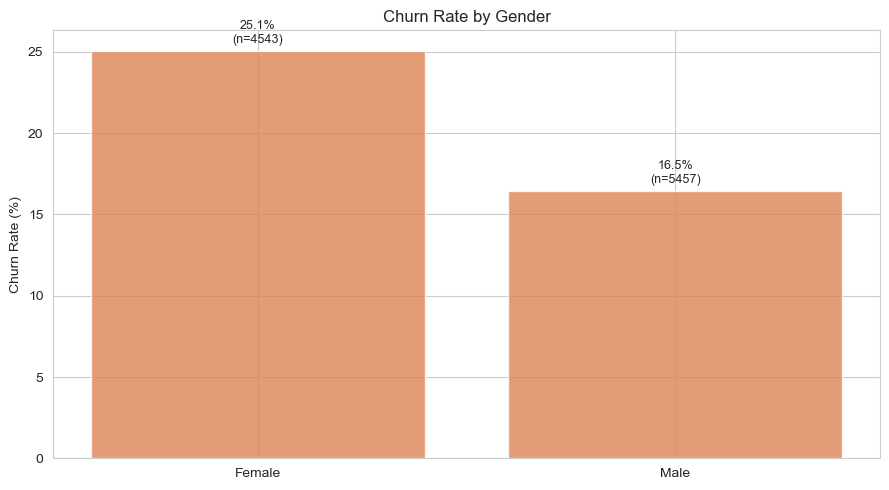

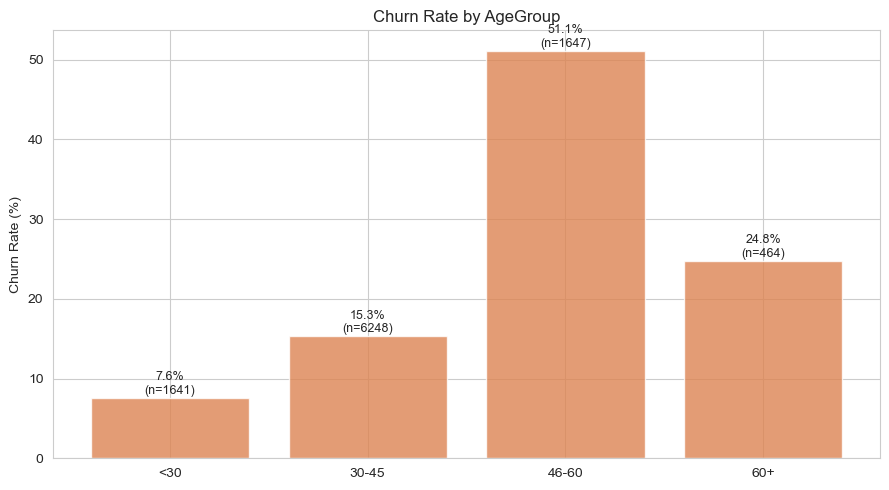

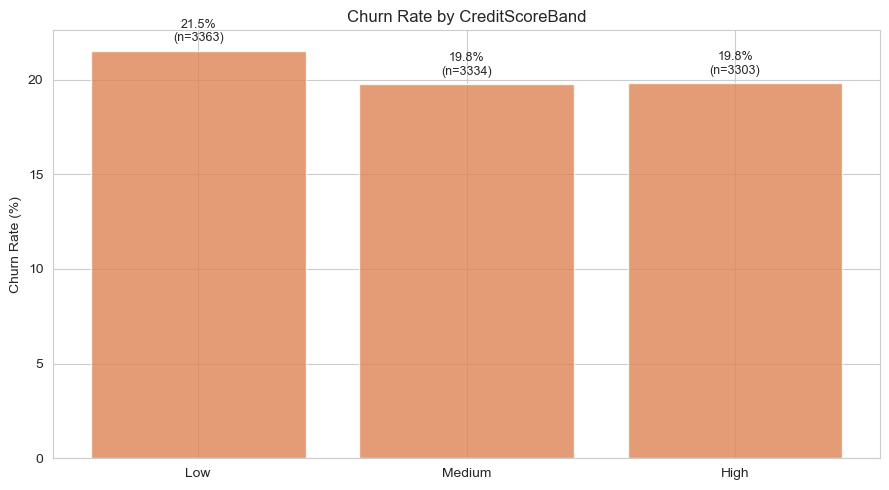

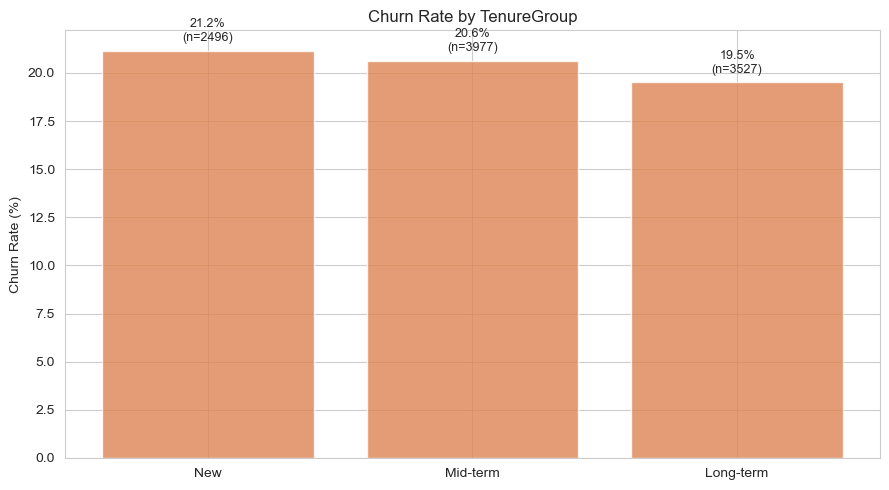

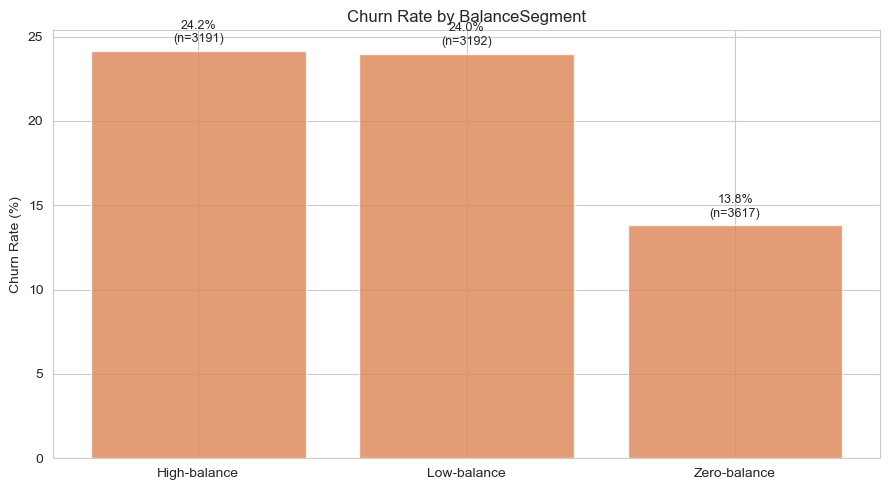

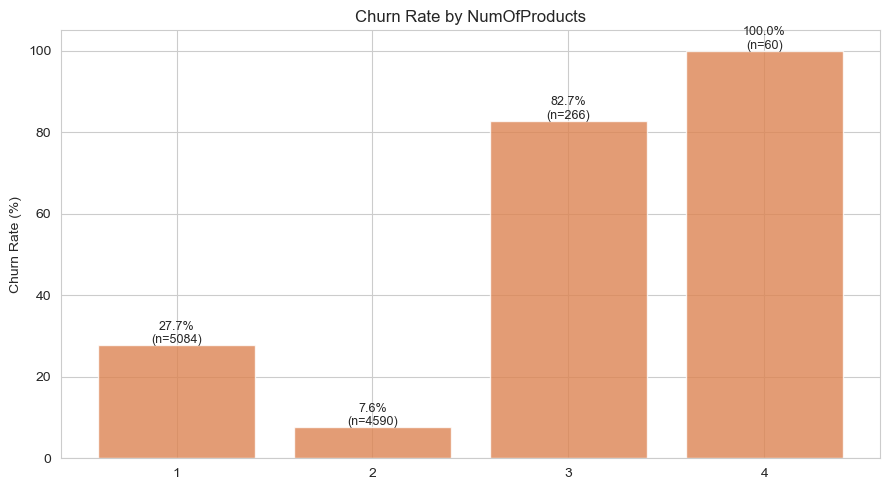

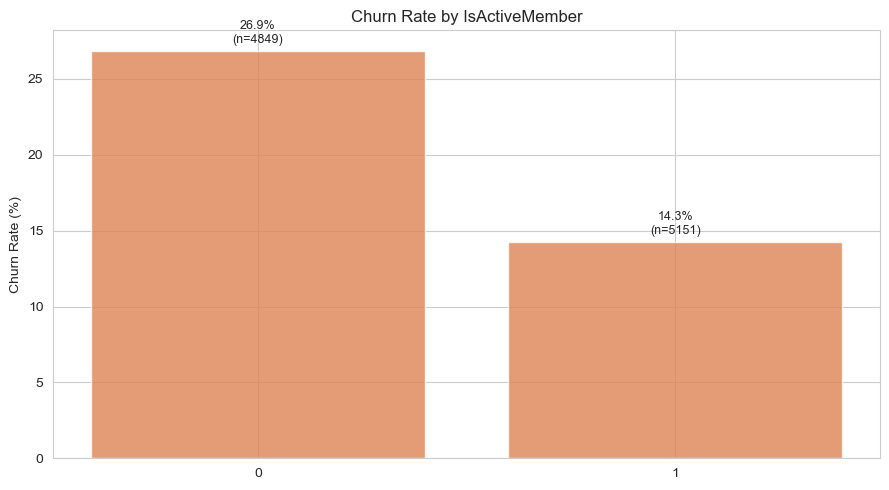

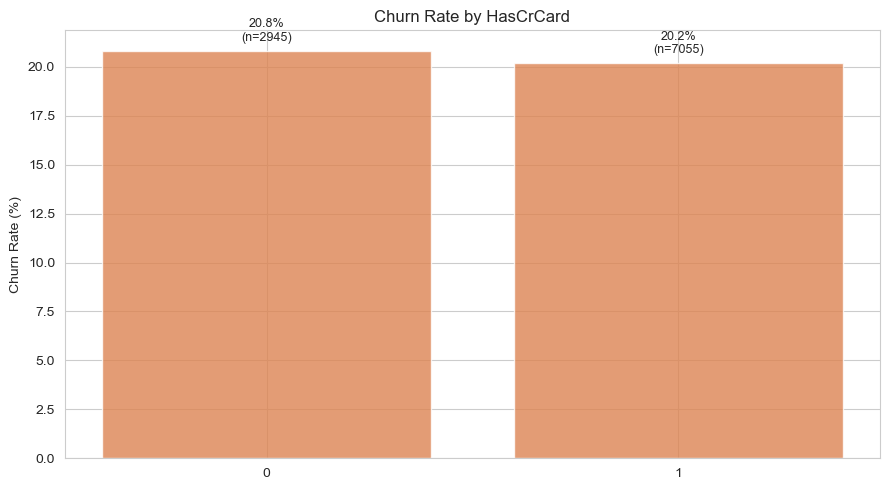

In [14]:
def plot_churn_by_segment(df, segment_col, title=None):
    churn_rate = df.groupby(segment_col, observed=True)['Exited'].mean() * 100
    segment_size = df.groupby(segment_col, observed=True)['Exited'].count()

    fig, ax1 = plt.subplots(figsize=(9, 5))
    bars = ax1.bar(churn_rate.index.astype(str), churn_rate.values, color='#DD8452', alpha=0.8)
    ax1.set_ylabel('Churn Rate (%)')
    ax1.set_title(title or f'Churn Rate by {segment_col}')

    for bar, size in zip(bars, segment_size.values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                  f'{height:.1f}%\n(n={size})', ha='center', fontsize=9)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Run for each segmentation dimension
for col in ['Geography', 'Gender', 'AgeGroup', 'CreditScoreBand', 'TenureGroup', 'BalanceSegment', 'NumOfProducts', 'IsActiveMember', 'HasCrCard']:
    plot_churn_by_segment(df_clean, col)

# Phase 4 — Comparative & Interaction Analysis

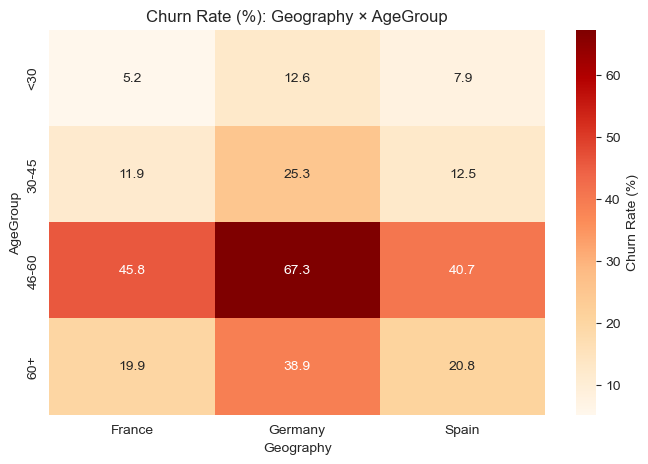

In [15]:
pivot_geo_age = df_clean.pivot_table(values='Exited', index='AgeGroup', columns='Geography', aggfunc='mean', observed=True) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_geo_age, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): Geography × AgeGroup')
plt.show()

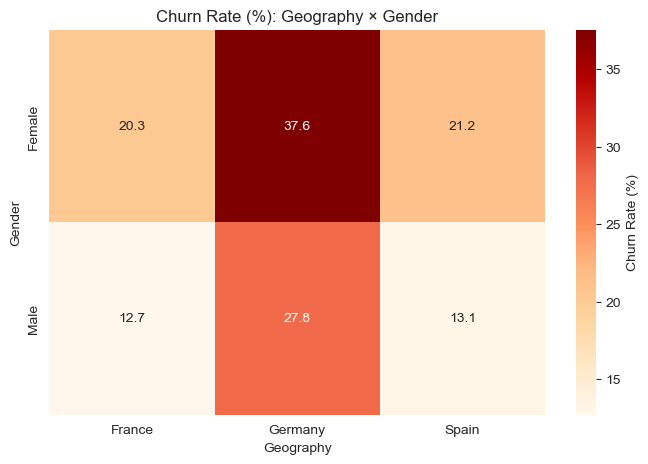

In [16]:
pivot_geo_gender = df_clean.pivot_table(values='Exited', index='Gender', columns='Geography', aggfunc='mean', observed=True) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_geo_gender, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): Geography × Gender')
plt.show()

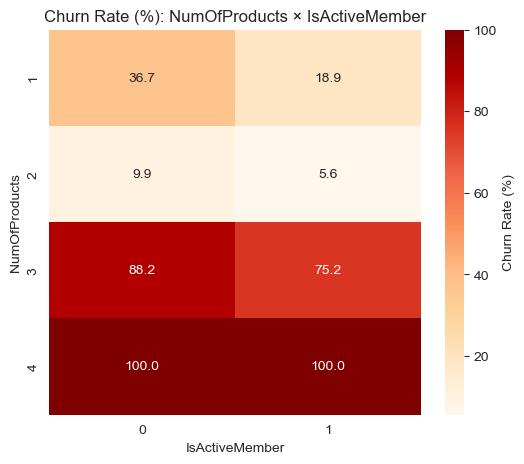

In [17]:
pivot_prod_active = df_clean.pivot_table(values='Exited', index='NumOfProducts', columns='IsActiveMember', aggfunc='mean', observed=True) * 100

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_prod_active, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): NumOfProducts × IsActiveMember')
plt.show()

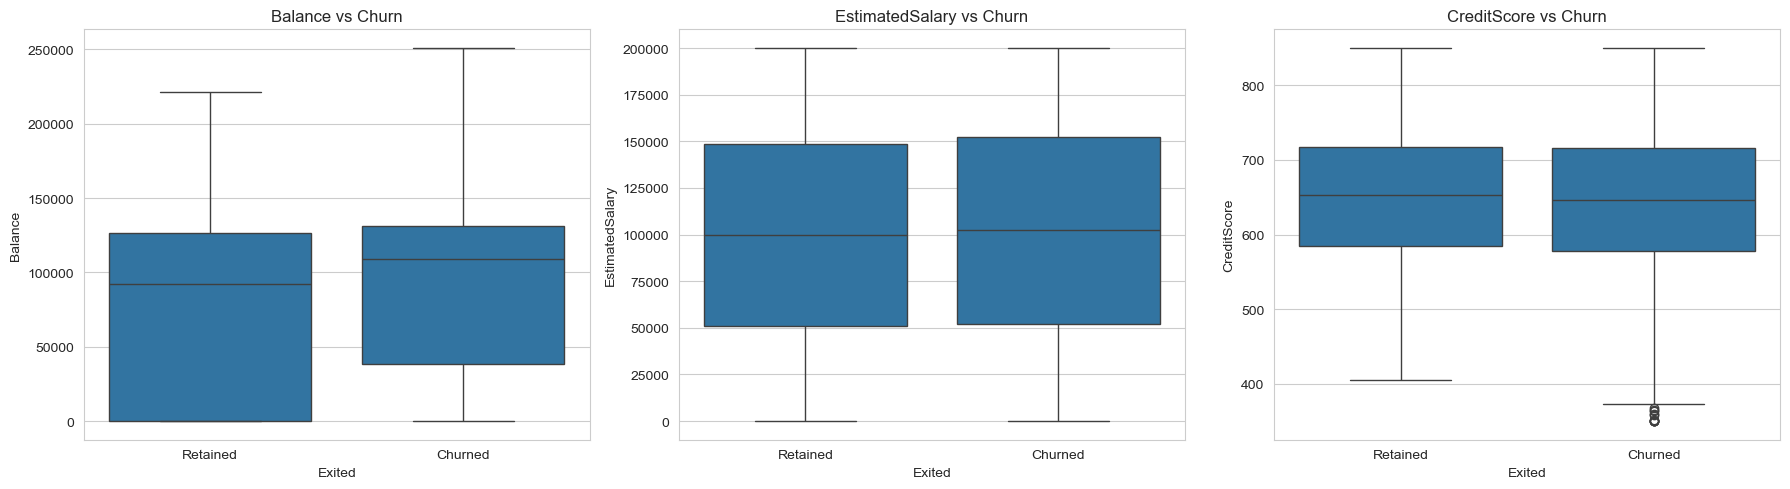

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Balance', 'EstimatedSalary', 'CreditScore']):
    sns.boxplot(data=df_clean, x='Exited', y=col, ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.set_xticklabels(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

# Phase 5 — High-Value Customer Churn Analysis

High-value threshold (Balance > 75th percentile): 127,644.24
High-value customer count: 2500 (25.0%)


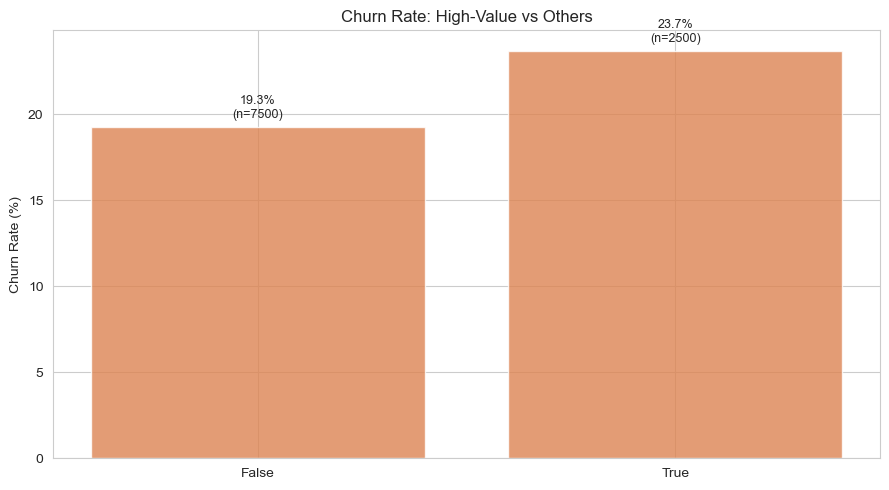

In [19]:
balance_p75 = df_clean['Balance'].quantile(0.75)
df_clean['HighValue'] = df_clean['Balance'] > balance_p75

print(f"High-value threshold (Balance > 75th percentile): {balance_p75:,.2f}")
print(f"High-value customer count: {df_clean['HighValue'].sum()} ({df_clean['HighValue'].mean()*100:.1f}%)")

plot_churn_by_segment(df_clean, 'HighValue', title='Churn Rate: High-Value vs Others')

In [20]:
high_value_churned = df_clean[(df_clean['HighValue']) & (df_clean['Exited'] == 1)]
total_balance_at_risk = high_value_churned['Balance'].sum()
total_bank_balance = df_clean['Balance'].sum()

print(f"High-value churned customers: {len(high_value_churned)}")
print(f"Total balance at risk (churned high-value): ${total_balance_at_risk:,.2f}")
print(f"As % of total bank balance: {total_balance_at_risk/total_bank_balance*100:.2f}%")

High-value churned customers: 592
Total balance at risk (churned high-value): $88,654,932.44
As % of total bank balance: 11.59%


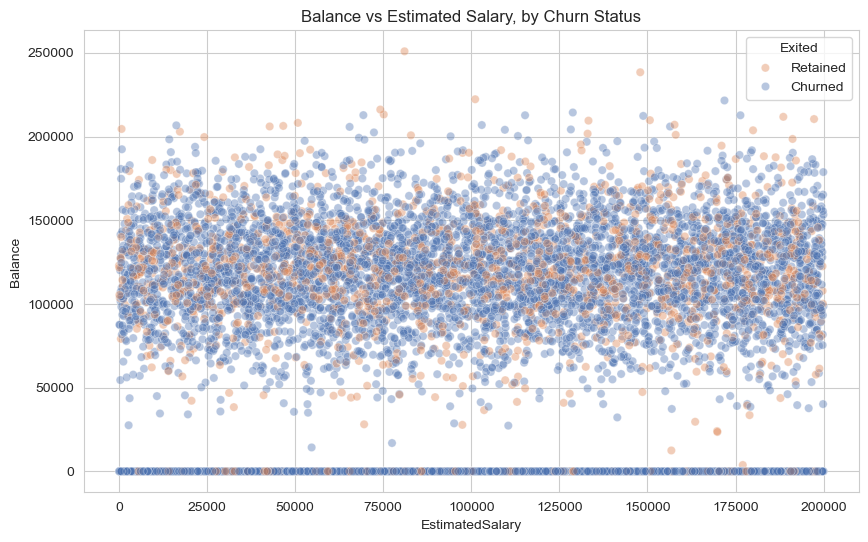

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='EstimatedSalary', y='Balance', hue='Exited',
                 alpha=0.4, palette={0: '#4C72B0', 1: '#DD8452'})
plt.title('Balance vs Estimated Salary, by Churn Status')
plt.legend(title='Exited', labels=['Retained', 'Churned'])
plt.show()

In [22]:
persona = df_clean.groupby('Exited')[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']].mean()
persona.index = ['Retained', 'Churned']
persona.round(1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Retained,651.9,37.4,5.0,72745.3,1.5,99738.4
Churned,645.4,44.8,4.9,91108.5,1.5,101465.7


# Phase 6 — Formalize the KPIs

In [23]:
# 1. Overall Churn Rate
overall_churn_rate = df_clean['Exited'].mean() * 100

# 2. Segment Churn Rate (generalized function)
def segment_churn_rate(df, segment_col):
    return (df.groupby(segment_col, observed=True)['Exited'].mean() * 100).round(2)

# 3. High-Value Churn Ratio (churned high-value / all churned)
high_value_churn_ratio = (df_clean[(df_clean['HighValue']) & (df_clean['Exited']==1)].shape[0]
                           / df_clean[df_clean['Exited']==1].shape[0]) * 100

# 4. Geographic Risk Index (segment churn rate relative to overall rate, as a ratio)
geo_churn = segment_churn_rate(df_clean, 'Geography')
geographic_risk_index = (geo_churn / overall_churn_rate).round(2)

# 5. Engagement Drop Indicator (churn rate ratio: inactive vs active)
active_churn = segment_churn_rate(df_clean, 'IsActiveMember')
engagement_drop_indicator = (active_churn[0] / active_churn[1]).round(2)

print(f"1. Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"\n2. Segment Churn Rate (example - Geography):\n{geo_churn}")
print(f"\n3. High-Value Churn Ratio: {high_value_churn_ratio:.2f}% of all churners are high-value")
print(f"\n4. Geographic Risk Index (ratio to overall):\n{geographic_risk_index}")
print(f"\n5. Engagement Drop Indicator: Inactive members churn {engagement_drop_indicator}x more than active")

1. Overall Churn Rate: 20.37%

2. Segment Churn Rate (example - Geography):
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

3. High-Value Churn Ratio: 29.06% of all churners are high-value

4. Geographic Risk Index (ratio to overall):
Geography
France     0.79
Germany    1.59
Spain      0.82
Name: Exited, dtype: float64

5. Engagement Drop Indicator: Inactive members churn 1.88x more than active


# Phase 7: Feature Engineering and Model Training

## Phase 7.1 — Feature Engineering Plan (reasoning first)

In [24]:
df_model = df_clean.copy()

# Binary encode Gender
df_model['Gender'] = df_model['Gender'].map({'Male': 0, 'Female': 1})

# One-hot encode Geography
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)  # drops France as baseline

# Engineered interaction features based on EDA findings
df_model['HighProductRisk'] = (df_model['NumOfProducts'] >= 3).astype(int)
df_model['GermanyMidAge'] = ((df_clean['Geography'] == 'Germany') & (df_clean['AgeGroup'] == '46-60')).astype(int)

# Drop columns not used as model features
drop_cols = ['CustomerId', 'AgeGroup', 'TenureGroup', 'CreditScoreBand', 'BalanceSegment', 'HighValue']
df_model = df_model.drop(columns=drop_cols)

print(df_model.columns.tolist())
print(df_model.shape)
df_model.head()

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'HighProductRisk', 'GermanyMidAge']
(10000, 14)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,HighProductRisk,GermanyMidAge
0,619,1,42,2,0.00,1,1,1,101348.88,1,False,False,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,False,True,0,0
2,502,1,42,8,159660.80,3,1,0,113931.57,1,False,False,1,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,False,False,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,False,True,0,0


In [25]:
print("HighProductRisk churn rate:\n", df_model.groupby('HighProductRisk')['Exited'].mean() * 100)
print("\nGermanyMidAge churn rate:\n", df_model.groupby('GermanyMidAge')['Exited'].mean() * 100)

HighProductRisk churn rate:
 HighProductRisk
0    18.162084
1    85.889571
Name: Exited, dtype: float64

GermanyMidAge churn rate:
 GermanyMidAge
0    17.887976
1    67.330677
Name: Exited, dtype: float64


In [26]:
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print("Feature columns:", X.columns.tolist())
print("X shape:", X.shape, "| y shape:", y.shape)
print("\nChurn ratio in y:", y.mean().round(4))

Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'HighProductRisk', 'GermanyMidAge']
X shape: (10000, 13) | y shape: (10000,)

Churn ratio in y: 0.2037


## Phase 7.2 — Train/Test Split & Scaling

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves 20.37% churn ratio in both sets
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train churn ratio:", y_train.mean().round(4))
print("Test churn ratio:", y_test.mean().round(4))

Train shape: (8000, 13) | Test shape: (2000, 13)
Train churn ratio: 0.2037
Test churn ratio: 0.2035


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit only on train, transform test — prevents data leakage

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,HighProductRisk,GermanyMidAge
2151,1.058568,-0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,-0.578313,-0.577735,-0.182185,-0.229416
8392,0.913626,-0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.729169,-0.577735,-0.182185,-0.229416
5006,1.079274,1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.729169,-0.577735,-0.182185,-0.229416
4117,-0.929207,-0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,-0.578313,-0.577735,-0.182185,-0.229416
7182,0.427035,-0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.729169,-0.577735,-0.182185,4.358899


## Phase 7.3 — Logistic Regression (Baseline Model)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

In [31]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of churn (class 1)

In [32]:
print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nFull classification report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy:  0.8440
Precision: 0.7363
Recall:    0.3636
F1 Score:  0.4868
ROC-AUC:   0.8369

Confusion Matrix:
[[1540   53]
 [ 259  148]]

Full classification report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1593
           1       0.74      0.36      0.49       407

    accuracy                           0.84      2000
   macro avg       0.80      0.67      0.70      2000
weighted avg       0.83      0.84      0.82      2000



In [33]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df)

              Feature  Coefficient
11    HighProductRisk     1.078977
5       NumOfProducts    -0.858697
2                 Age     0.652303
7      IsActiveMember    -0.521434
9   Geography_Germany     0.301011
1              Gender     0.254392
12      GermanyMidAge     0.247539
0         CreditScore    -0.076098
6           HasCrCard    -0.052637
8     EstimatedSalary     0.045678
10    Geography_Spain     0.031935
4             Balance    -0.030678
3              Tenure    -0.020061


## Phase 7.4 — Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [35]:
print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\n", classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy:  0.8260
Precision: 0.5566
Recall:    0.7125
F1 Score:  0.6250
ROC-AUC:   0.8649

Confusion Matrix:
[[1362  231]
 [ 117  290]]

               precision    recall  f1-score   support

           0       0.92      0.85      0.89      1593
           1       0.56      0.71      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.83      2000



In [36]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

              Feature  Importance
2                 Age    0.320271
5       NumOfProducts    0.219544
4             Balance    0.084800
11    HighProductRisk    0.074634
7      IsActiveMember    0.059076
12      GermanyMidAge    0.057172
8     EstimatedSalary    0.044415
9   Geography_Germany    0.042229
0         CreditScore    0.041404
3              Tenure    0.023631
1              Gender    0.020903
10    Geography_Spain    0.006117
6           HasCrCard    0.005806


## Phase 7.5 continued — XGBoost

In [37]:
# Run once if xgboost isn't installed:
# !pip install xgboost --quiet

from xgboost import XGBClassifier

In [38]:
# scale_pos_weight approximates class_weight='balanced' for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [39]:
print("=== XGBoost ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n", classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy:  0.8110
Precision: 0.5267
Recall:    0.7027
F1 Score:  0.6021
ROC-AUC:   0.8601

Confusion Matrix:
[[1336  257]
 [ 121  286]]

               precision    recall  f1-score   support

           0       0.92      0.84      0.88      1593
           1       0.53      0.70      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [40]:
importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_xgb)

              Feature  Importance
5       NumOfProducts    0.254914
7      IsActiveMember    0.160717
2                 Age    0.140075
9   Geography_Germany    0.096089
12      GermanyMidAge    0.065397
1              Gender    0.061914
4             Balance    0.059977
10    Geography_Spain    0.039268
0         CreditScore    0.033340
3              Tenure    0.032217
8     EstimatedSalary    0.032202
6           HasCrCard    0.023890
11    HighProductRisk    0.000000


## Phase 7.6 — Formal Comparison Table, ROC Curves, Cross-Validation

In [42]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb)],
    'F1': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)]
}).round(4)

print(results)

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression     0.844     0.7363  0.3636  0.4868   0.8369
1        Random Forest     0.826     0.5566  0.7125  0.6250   0.8649
2              XGBoost     0.811     0.5267  0.7027  0.6021   0.8601


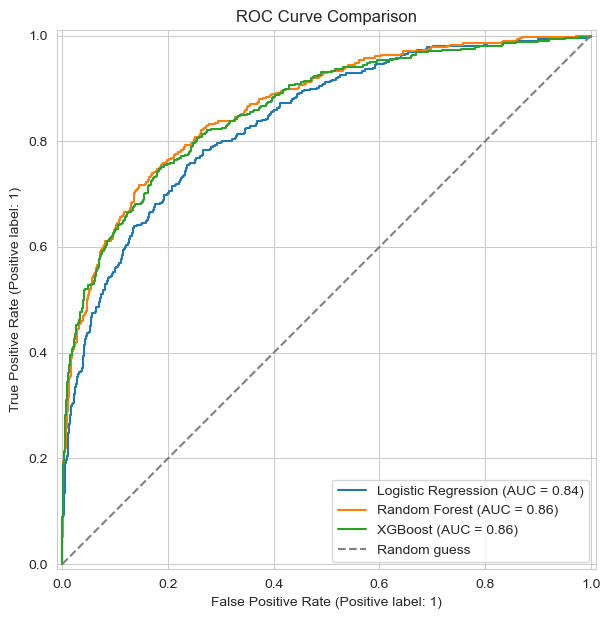

In [43]:
fig, ax = plt.subplots(figsize=(8, 7))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost', ax=ax)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(rf, X, y, cv=skf, scoring='f1')
cv_recall = cross_val_score(rf, X, y, cv=skf, scoring='recall')
cv_auc = cross_val_score(rf, X, y, cv=skf, scoring='roc_auc')

print(f"CV F1 scores:     {cv_f1.round(4)} | Mean: {cv_f1.mean():.4f}")
print(f"CV Recall scores: {cv_recall.round(4)} | Mean: {cv_recall.mean():.4f}")
print(f"CV AUC scores:    {cv_auc.round(4)} | Mean: {cv_auc.mean():.4f}")

CV F1 scores:     [0.6154 0.5955 0.6142 0.6135 0.6591] | Mean: 0.6195
CV Recall scores: [0.6961 0.6422 0.6904 0.6904 0.7174] | Mean: 0.6873
CV AUC scores:    [0.8645 0.8505 0.8638 0.8653 0.8683] | Mean: 0.8625


## Phase 7.7 — Interpretability (SHAP)

In [47]:
# Run once if not installed:
!pip install shap --quiet

import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class_0, class_1] in older SHAP versions,
# or a single array in newer versions — this handles both
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

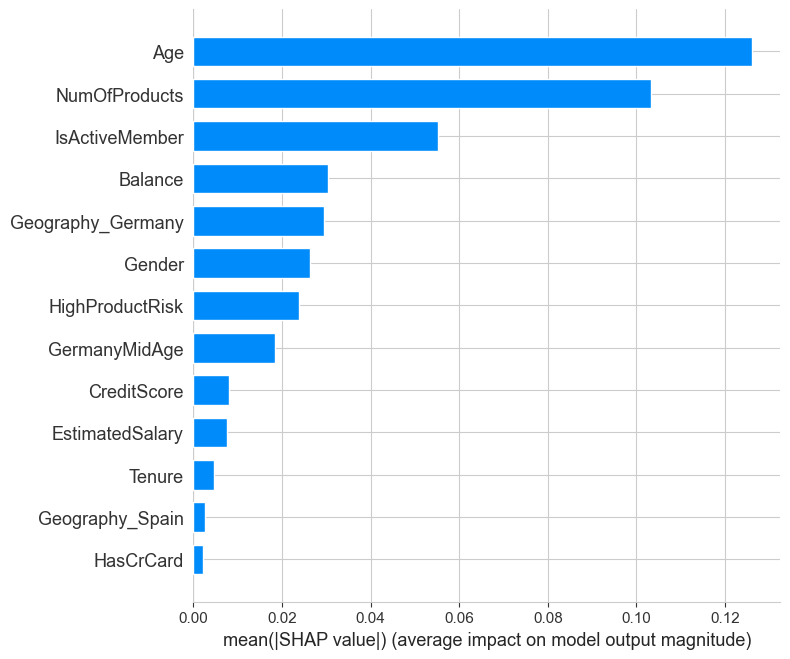

In [48]:
shap.summary_plot(shap_values_churn, X_test, plot_type='bar')

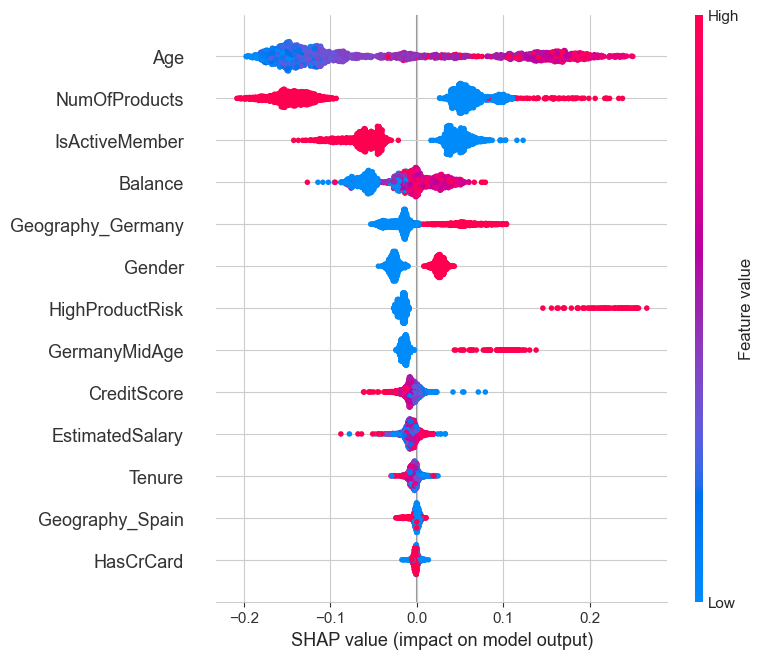

In [49]:
shap.summary_plot(shap_values_churn, X_test)

# Phase 8: Save the Model Artifacts

In [50]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(rf, 'models/random_forest_churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_columns.pkl')

print("Model, scaler, and feature columns saved to /models")

Model, scaler, and feature columns saved to /models


In [51]:
df_clean.to_csv('data/df_clean_for_dashboard.csv', index=False)
print("Cleaned dataset saved for dashboard use.")

Cleaned dataset saved for dashboard use.
